In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_t', 'sim',
        '--data_path', '../../data/delay/tesla_sim.csv',
        '--data_nsample', '300',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '10',
        '--patience', '3',
        '--checkpoints', '../../models',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"exp": 2, "sin": 3, "cos": 3}',
        '--fun_trans', '{"data": 8}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.337852, valid=0.053197, test=0.181948
	validation loss decreased (inf -> 0.053197), saving model ...
	epoch 2 losses: train=0.310144, valid=0.052548, test=0.165300
	validation loss decreased (0.053197 -> 0.052548), saving model ...
	epoch 3 losses: train=0.265530, valid=0.063811, test=0.137056
	early stopping counter: 1 out of 3
	epoch 4 losses: train=0.214910, valid=0.046538, test=0.122776
	validation loss decreased (0.052548 -> 0.046538), saving model ...
	epoch 5 losses: train=0.159581, valid=0.037472, test=0.100461
	validation loss decreased (0.046538 -> 0.037472), saving model ...
	epoch 6 losses: train=0.114187, valid=0.028524, test=0.083830
	validation loss decreased (0.037472 -> 0.028524), saving model ...
	epoch 7 losses: train=0.088879, valid=0.026297, test=0.077874
	validation loss decreased (0.028524 -> 0.026297), saving model ...
	epoch 8 losses: train=0.074640, valid=0.025707, test=0.067482
	validation loss decreased 

In [6]:
data_loader = dataset.load(flag='test')
model.eval()

model(
  (stationary): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=96, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=1344, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=16, out_features=8, bias=False)
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=16, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=192, bias=T

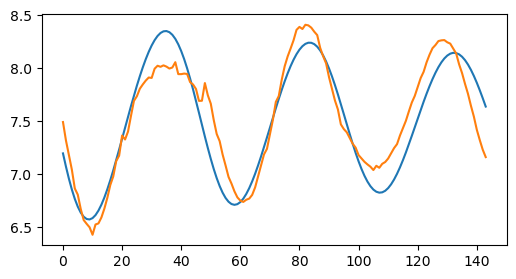

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break